In [1]:
!pip install openpyxl

In [2]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("../data/moscow_transformed.xlsx").set_index(["ID на сайте", "Источник"], drop = False)
df.head()

,,ID на сайте,Источник,Название,Цена,Дата,Тип автора,Метро/Район,Адрес,lat,lng,URL,Ссылки на картинки,"Расстояние до метро, км",Этаж,Этажность здания,Вид объекта,Общая площадь
ID на сайте,Источник,,,,,,,,,,,,,,,,,
320731003,cian.ru,320731003,cian.ru,"Офис в Москва Шипиловская ул., 58к1 (25 м²)",38800,2025-08-23 02:23:27,Агентство,Шипиловская,"Шипиловская ул., 58к1",55.621211,37.745600,https://www.cian.ru/rent/commercial/320731003,['https://images.cdn-cian.ru/images/2592583348...,0.083,4.0,6.0,Офисное помещение,25.0
321876001,cian.ru,321876001,cian.ru,"Офис в Москва Ленинградский просп., 47С2 (25 м²)",31250,2025-09-25 20:21:36,Агентство,Аэропорт,"Ленинградский просп., 47С2",55.799036,37.532601,https://www.cian.ru/rent/commercial/321876001,['https://images.cdn-cian.ru/images/2631122267...,0.250,-2.0,7.0,Офисное помещение,25.0
322186790,cian.ru,322186790,cian.ru,"Офис в Москва Волгоградский просп., 2 (20 м²)",29200,2025-09-25 10:22:06,Агентство,Пролетарская,"Волгоградский просп., 2",55.731176,37.669279,https://www.cian.ru/rent/commercial/322186790,['https://images.cdn-cian.ru/images/2641248288...,0.250,6.0,16.0,Офисное помещение,20.0
321392086,cian.ru,321392086,cian.ru,Помещение свободного назначения в Москва ул. А...,32000,2025-09-02 04:23:10,Частное лицо,Бунинская Аллея,"ул. Адмирала Руднева, 20",55.540409,37.516153,https://www.cian.ru/rent/commercial/321392086,['https://images.cdn-cian.ru/images/nezhiloe-p...,0.250,3.0,7.0,Торговое / Свободного назначения,32.0
324943206,cian.ru,324943206,cian.ru,"Офис в Москва просп. Мира, 95С1 (24 м²)",44000,2025-12-11 16:28:22,Агентство,Алексеевская,"просп. Мира, 95С1",55.808002,37.635853,https://www.cian.ru/rent/commercial/324943206,['https://images.cdn-cian.ru/images/ofis-moskv...,0.167,14.0,17.0,Офисное помещение,24.0


In [3]:
df.dtypes

ID на сайте                         int64
Источник                           object
Название                           object
Цена                                int64
Дата                       datetime64[ns]
Тип автора                         object
Метро/Район                        object
Адрес                              object
lat                               float64
lng                               float64
URL                                object
Ссылки на картинки                 object
Расстояние до метро, км           float64
Этаж                              float64
Этажность здания                  float64
Вид объекта                        object
Общая площадь                     float64
dtype: object

In [4]:
df.columns

Index(['ID на сайте', 'Источник', 'Название', 'Цена', 'Дата', 'Тип автора',
       'Метро/Район', 'Адрес', 'lat', 'lng', 'URL', 'Ссылки на картинки',
       'Расстояние до метро, км', 'Этаж', 'Этажность здания', 'Вид объекта',
       'Общая площадь'],
      dtype='object')

In [5]:
df.isna().sum()

ID на сайте                  0
Источник                     0
Название                     0
Цена                         0
Дата                         0
Тип автора                   0
Метро/Район                  0
Адрес                        4
lat                          0
lng                          0
URL                          0
Ссылки на картинки         148
Расстояние до метро, км      0
Этаж                       123
Этажность здания           128
Вид объекта                  1
Общая площадь                0
dtype: int64

In [6]:
df = df.dropna(subset="Вид объекта")

In [7]:
df["Метро/Район"].nunique()

315

# Трансформации

**Hack:** `OrdinalEncoder` нам создает некий ненужный порядок, которого у нас нет. Однако его можно ввести: достаточно понять влияние той или иной категории на таргет. Условно, делаем `TargetEncoding` -- назначаем метки по мере возрастания значения (дополнительно еще зашумляем и сглаживает). Так мы избегаем и сильной утечки таргета, и сохраняем важные данные.

In [8]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import TargetEncoder


class OrdinalByTargetEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.te = TargetEncoder(target_type="continuous", random_state=10)

    def fit(self, X, y):
        self.te = self.te.fit(X, y)
        
    def transform(self, X, y=None):
        X_copy = X.copy()
        for i, col in enumerate(X.columns):
            cat_dict = dict(zip(self.te.categories_[i], self.te.encodings_[i]))
            ordinal_categories = sorted(cat_dict, key=cat_dict.get)
            ordinal_mapping = dict(zip(ordinal_categories, range(len(ordinal_categories))))
            X_copy[col] = X_copy[col].map(ordinal_mapping)
            X_copy[col] = X_copy[col].fillna(len(ordinal_categories) // 2)
        return X_copy

    def fit_transform(self, X, y):
        self.fit(X, y)
        return self.transform(X)

    def set_output(self, *, transform=None):
        """Scikit-learn 1.2+ requirement"""
        return self

In [9]:
data = pd.read_csv("geo_data.csv")
data = data.dropna(subset=["lat", "lon", "rubrics"])

In [10]:
from collections import Counter

data["rub_list"] = (
    data["rubrics"]
        .astype(str)
        .str.split(";")
        .apply(lambda x: [s.strip() for s in x if s.strip()])
)

all_rubrics = Counter(x for lst in data["rub_list"] for x in lst)
keep_rubrics = {k for k, v in all_rubrics.items() if v >= 100}

In [11]:
from sklearn.neighbors import BallTree

EARTH_R = 6371000.0

coords_data = np.radians(data[["lat", "lon"]].values)
tree = BallTree(coords_data, metric  = "haversine")

def get_lst(lat, lon, R_m):
    idxs = tree.query_radius(np.radians([[lat, lon]]), r = R_m / EARTH_R)[0]
    lst = {}
    for i in idxs:
        for r in data.iloc[i]["rub_list"]:
            if r in keep_rubrics:
                lst[r] = lst.get(r, 0) + 1
    return lst

R = 600

geo = []
for i, row in df.iterrows():
    geo.append(get_lst(row["lat"], row["lng"], R))

geo_df = pd.DataFrame(geo).fillna(0).astype(int)
geo_df.columns = [f"cnt_{c.replace(' ', '_')}" for c in geo_df.columns]
geo_cols = geo_df.columns.tolist()

df = pd.concat([df.reset_index(drop=True), geo_df.reset_index(drop=True)], axis=1)

In [12]:
data2 = pd.read_csv("moscow_super_ultra_transformed.csv").set_index(["ID на сайте", "Источник"])
data2 = data2.drop("Unnamed: 0", axis = 1)
data2

,,n_buildings_300m,n_living_buildings_300m,n_flats_300m,min_bc_distance_300m,mean_bc_distance_300m,traffic1_300m,traffic2_300m,traffic3_300m,traffic4_300m,Медицина_300,...,Ветаптеки и ветклиники_600,Магазины цветов_600,"Прачечные, химчистки_600",Детские игровые залы_600,Религия_600,"Пиццерии, суши, столовые_600","Пекарни, кофейни_600","Кафе, бары, рестораны_600",Социальные_600,Банки_600
ID на сайте,Источник,,,,,,,,,,,,,,,,,,,,,
320731003,cian.ru,38.0,14.000000,3610.000000,0.0,123.500000,8176.0,6091.0,1557.0,1713.0,3.0,...,8.0,8.0,7.0,0.0,0.0,3.0,7.0,11.0,8.0,1.0
321876001,cian.ru,54.0,15.000000,1287.000000,0.0,82.666667,9392.0,38428.0,1513.0,11424.0,4.0,...,3.0,12.0,9.0,0.0,0.0,10.0,34.0,30.0,5.0,2.0
322186790,cian.ru,44.0,22.000000,3234.000000,9.0,178.200000,8304.0,19462.0,2032.0,6787.0,7.0,...,10.0,17.0,15.0,0.0,1.0,11.0,29.0,29.0,10.0,2.0
321392086,cian.ru,23.0,8.000000,1831.000000,10.0,10.000000,4194.0,4593.0,2101.0,3820.0,3.0,...,1.0,6.0,3.0,0.0,1.0,4.0,7.0,9.0,5.0,0.0
324943206,cian.ru,46.0,30.000000,3647.000000,4.0,117.000000,7146.0,24972.0,4008.0,17350.0,14.0,...,6.0,8.0,15.0,0.0,1.0,16.0,27.0,29.0,10.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306948989166313984,realty.yandex.ru,46.0,22.000000,4017.000000,199.0,199.000000,1936.0,387.0,1921.0,1232.0,2.0,...,7.0,5.0,8.0,0.0,1.0,4.0,15.0,11.0,5.0,2.0
306948989166314816,realty.yandex.ru,33.0,13.000000,1973.000000,0.0,143.200000,2822.0,6195.0,2914.0,2465.0,0.0,...,3.0,5.0,1.0,1.0,0.0,6.0,8.0,9.0,3.0,1.0
306948989166338880,realty.yandex.ru,118.0,34.000000,2036.000000,0.0,186.225806,1414.0,14784.0,1200.0,9019.0,7.0,...,1.0,18.0,14.0,1.0,9.0,23.0,43.0,74.0,13.0,5.0


In [13]:
df = df.join(data2, on=["ID на сайте", "Источник"], how="left")
df

,ID на сайте,Источник,Название,Цена,Дата,Тип автора,Метро/Район,Адрес,lat,lng,...,Ветаптеки и ветклиники_600,Магазины цветов_600,"Прачечные, химчистки_600",Детские игровые залы_600,Религия_600,"Пиццерии, суши, столовые_600","Пекарни, кофейни_600","Кафе, бары, рестораны_600",Социальные_600,Банки_600
0,320731003,cian.ru,"Офис в Москва Шипиловская ул., 58к1 (25 м²)",38800,2025-08-23 02:23:27,Агентство,Шипиловская,"Шипиловская ул., 58к1",55.621211,37.745600,...,8.0,8.0,7.0,0.0,0.0,3.0,7.0,11.0,8.0,1.0
1,321876001,cian.ru,"Офис в Москва Ленинградский просп., 47С2 (25 м²)",31250,2025-09-25 20:21:36,Агентство,Аэропорт,"Ленинградский просп., 47С2",55.799036,37.532601,...,3.0,12.0,9.0,0.0,0.0,10.0,34.0,30.0,5.0,2.0
2,322186790,cian.ru,"Офис в Москва Волгоградский просп., 2 (20 м²)",29200,2025-09-25 10:22:06,Агентство,Пролетарская,"Волгоградский просп., 2",55.731176,37.669279,...,10.0,17.0,15.0,0.0,1.0,11.0,29.0,29.0,10.0,2.0
3,321392086,cian.ru,Помещение свободного назначения в Москва ул. А...,32000,2025-09-02 04:23:10,Частное лицо,Бунинская Аллея,"ул. Адмирала Руднева, 20",55.540409,37.516153,...,1.0,6.0,3.0,0.0,1.0,4.0,7.0,9.0,5.0,0.0
4,324943206,cian.ru,"Офис в Москва просп. Мира, 95С1 (24 м²)",44000,2025-12-11 16:28:22,Агентство,Алексеевская,"просп. Мира, 95С1",55.808002,37.635853,...,6.0,8.0,15.0,0.0,1.0,16.0,27.0,29.0,10.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9064,3987628968735107072,realty.yandex.ru,Офис (1200 м²),6000000,2025-09-05 16:00:52,Агентство,Шелепиха,"1-й Магистральный тупик, 5А",55.766132,37.531956,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9065,322424654,cian.ru,"Офис в Москва Сколковское ш., вл43 (1149 м²)",6894000,2025-10-03 08:21:53,Агентство,Кунцевская,"Сколковское ш., вл43",55.699654,37.397701,...,0.0,1.0,1.0,0.0,1.0,0.0,1.0,3.0,0.0,0.0
9066,7523548143730329600,realty.yandex.ru,Офис (967 м²),6769000,2025-10-22 07:59:36,Агентство,Немчиновка,"Сколковское шоссе, вл43",55.699654,37.397700,...,3.0,2.0,1.0,0.0,1.0,0.0,7.0,7.0,4.0,0.0
9067,322670014,cian.ru,"Офис в Москва Сколковское ш., вл43 (1134 м²)",7938000,2025-10-11 14:21:23,Агентство,Кунцевская,"Сколковское ш., вл43",55.699654,37.397701,...,0.0,1.0,1.0,0.0,1.0,0.0,1.0,3.0,0.0,0.0


In [14]:
df = df.dropna(subset=["n_buildings_300m"])

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder, # OrdinalEncoder, TargetEncoder,
    StandardScaler, # MinMaxScaler, RobustScaler,
)

from sklearn import set_config
set_config(transform_output="pandas")

data2_cols = [c for c in data2.columns if c not in ["ID на сайте", "Источник"]]

ct = ColumnTransformer(
    transformers=[
        ("scale", StandardScaler(),["Общая площадь", "Расстояние до метро, км", "Этаж"] + geo_cols + data2_cols),
        ("onehot", OneHotEncoder(drop="if_binary", sparse_output=False), ["Вид объекта", "Тип автора"]),
        ("ordinal", OrdinalByTargetEncoder(), ["Метро/Район"]),
    ],
    remainder="passthrough",
    n_jobs=-1,
    verbose_feature_names_out = False
).set_output(transform="pandas")

In [16]:
from sklearn.model_selection import train_test_split

X = df[
    ["Общая площадь", "Расстояние до метро, км", "Этаж"]
    + geo_cols
    + ["Вид объекта", "Тип автора", "Метро/Район"]
    + list(data2.columns)
].copy()

y = df["Цена"].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=X["Вид объекта"])

In [17]:
X_train["Вид объекта"].value_counts() / X_train.shape[0] * 100

Вид объекта
Офисное помещение                   63.817810
Торговое / Свободного назначения    34.885705
Здание                               1.296486
Name: count, dtype: float64

In [18]:
X_test["Вид объекта"].value_counts() / X_test.shape[0] * 100

Вид объекта
Офисное помещение                   63.785166
Торговое / Свободного назначения    34.884910
Здание                               1.329923
Name: count, dtype: float64

In [19]:
X_train.isna().sum()

Общая площадь                    0
Расстояние до метро, км          0
Этаж                            93
cnt_Детский_сад,_ясли            0
cnt_Магазин_пива                 0
                                ..
Пиццерии, суши, столовые_600     0
Пекарни, кофейни_600             0
Кафе, бары, рестораны_600        0
Социальные_600                   0
Банки_600                        0
Length: 167, dtype: int64

In [20]:
X_test.isna().sum()

Общая площадь                    0
Расстояние до метро, км          0
Этаж                            30
cnt_Детский_сад,_ясли            0
cnt_Магазин_пива                 0
                                ..
Пиццерии, суши, столовые_600     0
Пекарни, кофейни_600             0
Кафе, бары, рестораны_600        0
Социальные_600                   0
Банки_600                        0
Length: 167, dtype: int64

In [21]:
floor_mode = X_train["Этаж"].mode().values[0]
X_train["Этаж"] = X_train["Этаж"].fillna(floor_mode)
X_test["Этаж"] = X_test["Этаж"].fillna(floor_mode)

In [22]:
ct = ct.fit(X_train, y_train)
X_train_base = ct.transform(X_train)
X_test_base = ct.transform(X_test)

X_train_base

,Общая площадь,"Расстояние до метро, км",Этаж,"cnt_Детский_сад,_ясли",cnt_Магазин_пива,cnt_Доставка_цветов_и_букетов,cnt_Магазин_цветов,cnt_Салон_красоты,cnt_Массажный_салон,cnt_Ногтевая_студия,...,"Пиццерии, суши, столовые_600","Пекарни, кофейни_600","Кафе, бары, рестораны_600",Социальные_600,Банки_600,Вид объекта_Здание,Вид объекта_Офисное помещение,Вид объекта_Торговое / Свободного назначения,Тип автора_Частное лицо,Метро/Район
6030,0.184265,-0.397241,-0.278757,-0.524283,1.794307,0.514742,0.981621,0.060509,-0.191146,-0.268468,...,0.052644,-0.373839,-0.185214,-0.188869,-0.404846,0.0,1.0,0.0,0.0,170
1678,-0.596132,-0.359331,-0.416352,-0.524283,1.794307,3.993698,2.629463,0.429224,0.314266,0.806322,...,0.597269,0.608228,0.350298,1.769222,0.329053,0.0,0.0,1.0,0.0,190
5067,-0.203242,2.348493,-0.003568,-0.524283,-0.447429,0.514742,0.157700,-0.861278,-0.696558,-0.805863,...,-0.128898,-0.467369,-0.681058,-0.678392,-0.404846,0.0,1.0,0.0,1.0,282
4539,-0.714537,-0.397241,-0.416352,-0.524283,-0.447429,-0.644911,-0.666221,0.060509,1.830501,0.000229,...,1.958831,1.917650,1.322152,0.545415,-0.404846,0.0,0.0,1.0,0.0,198
6780,0.302670,-0.246505,-0.003568,1.252218,1.794307,0.514742,1.805542,0.797938,0.819678,0.806322,...,0.869582,0.093812,0.171794,2.258745,2.163800,0.0,1.0,0.0,0.0,211
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3599,-0.779122,-0.472157,-0.416352,-0.524283,1.794307,-0.644911,-0.666221,0.060509,-0.696558,-0.268468,...,1.323436,0.982348,0.370132,1.524461,0.329053,0.0,0.0,1.0,0.0,283
319,-0.757593,-0.058763,-0.003568,1.252218,-0.447429,0.514742,0.981621,-0.123848,-0.191146,0.268927,...,-0.582752,-0.841489,-0.720725,0.300654,-0.771795,0.0,1.0,0.0,0.0,33
1685,-0.553076,-0.284415,-0.141162,-0.524283,-0.447429,-0.644911,-0.666221,-0.861278,-0.696558,-0.805863,...,-0.310439,-0.514134,-0.641390,-1.167915,-0.404846,0.0,1.0,0.0,0.0,31
2308,-0.633806,1.520801,-0.416352,-0.524283,-0.447429,-0.644911,-0.666221,-0.861278,-0.696558,-0.805863,...,-1.127377,-1.075315,-0.899229,-1.167915,-0.771795,0.0,0.0,1.0,1.0,42


# Модель

In [23]:
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, QuantileRegressor
)

from sklearn.metrics import (
    r2_score,
    root_mean_squared_error as rmse,
    mean_absolute_percentage_error as mape,
)

def print_metrics(y_true, y_pred, dataset):
    print(f"{dataset} metrics:")
    print(f"\t  R2: {r2_score(y_true, y_pred) * 100:.2f}%")
    print(f"\tRMSE: {rmse(y_true, y_pred):.2f} руб.")
    print(f"\tMAPE: {mape(y_true, y_pred) * 100:.2f}%")

In [24]:
import sys

sys.path.append("..")

import viz

## Линейка

train metrics:
	  R2: 76.80%
	RMSE: 659692.88 руб.
	MAPE: 95.19%

test metrics:
	  R2: 72.56%
	RMSE: 711743.02 руб.
	MAPE: 95.29%


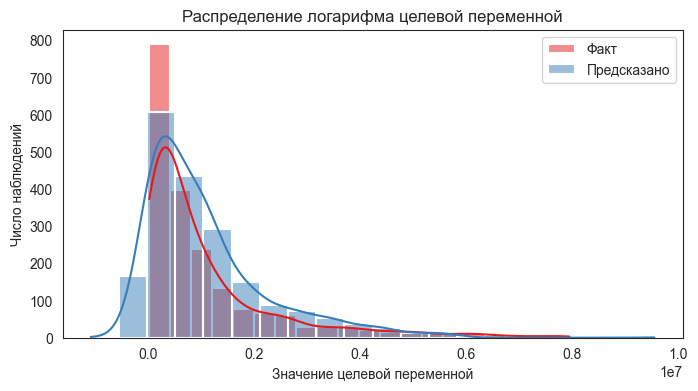

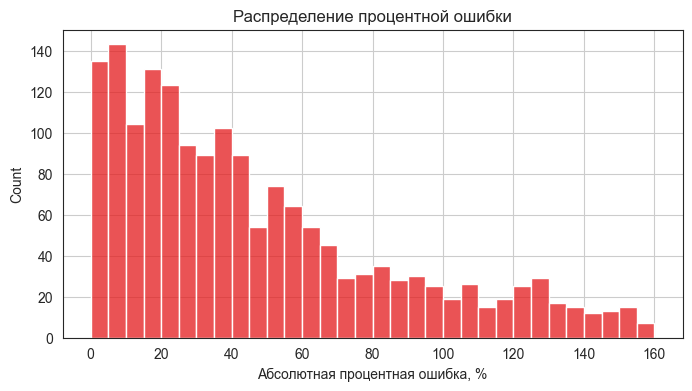

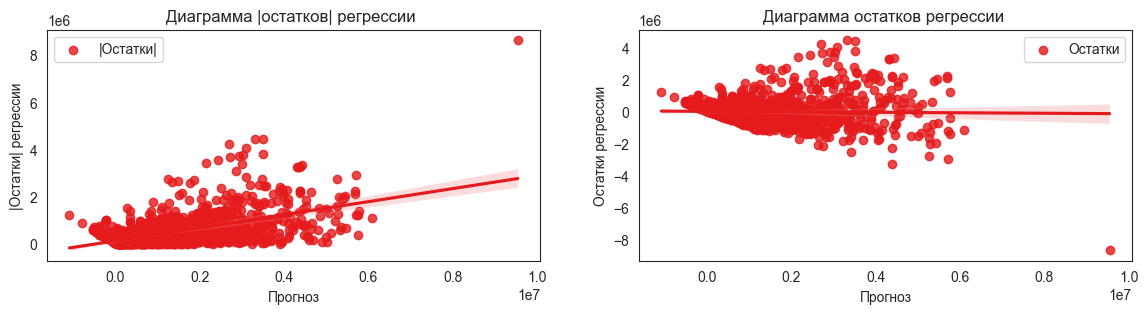

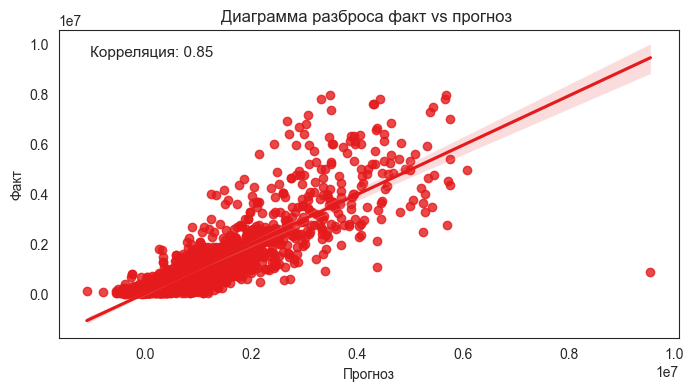

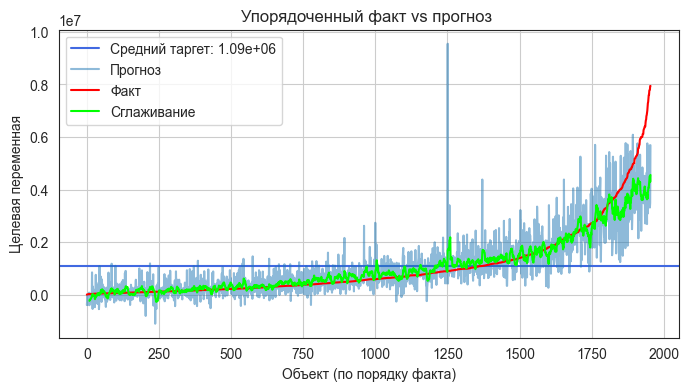

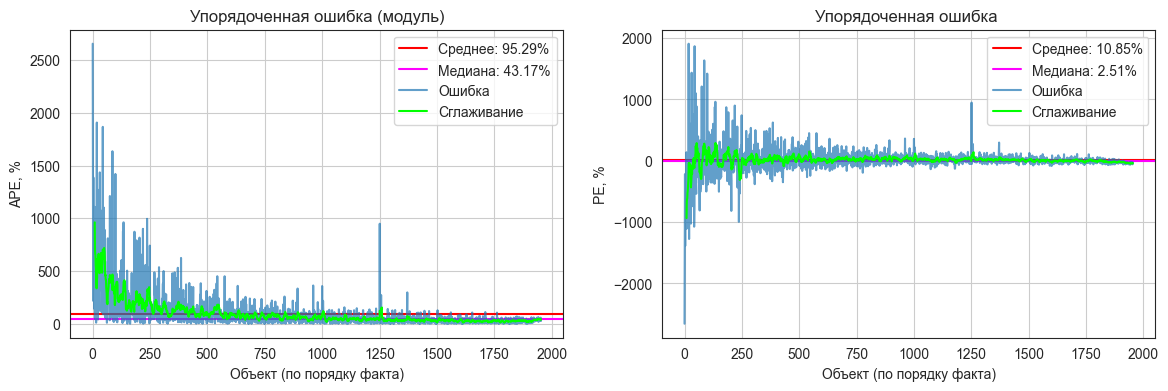

In [25]:
model = LinearRegression().fit(X_train_base, y_train)
y_pred = model.predict(X_train_base)
y_test_pred = model.predict(X_test_base)

print_metrics(y_train, y_pred, "train")
print()
print_metrics(y_test, y_test_pred, "test")

viz.plot_target_hist(y_test, y_test_pred)
viz.plot_ape_bins(y_test, y_test_pred)
viz.plot_regression_residuals(y_test, y_test_pred)
viz.plot_scatter(y_test, y_test_pred)
viz.plot_predict_sorted(y_test.values, y_test_pred, window=10)
viz.plot_ape_sorted(y_test.values, y_test_pred, window=10)

In [26]:
!pip install -q optuna

In [27]:
# import optuna
# from sklearn.model_selection import KFold
# from sklearn.model_selection import cross_validate
# optuna.logging.set_verbosity(optuna.logging.WARNING)


# FIXED_KWARGS = {
#     'tol': 1e-5,
#     'random_state': 42,
# }

# CV = KFold(n_splits=5, random_state=10, shuffle=True)

# def objective(trial, X, y):
#     params = {
#         'alpha': trial.suggest_float('alpha', low=0.0001, high=50),
#         'max_iter': trial.suggest_int('max_iter', low=500, high=3000),
#         'solver': trial.suggest_categorical('solver', ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga']),
#     }
    
#     params.update(FIXED_KWARGS)
#     model = Ridge(**params).fit(X, y)
#     scores = cross_validate(
#         model,
#         X, y,
#         scoring="r2", # https://scikit-learn.org/stable/modules/model_evaluation.html
#         cv=CV,
#         n_jobs=-1,
#     )
#     return scores['test_score'].mean()


# def study_results(study):
#     trial = study.best_trial
#     print('Best CV={} score: {:.6}'.format(CV, trial.value))
#     print('Best params:')
#     for key, value in trial.params.items():
#         print("    {}: {}".format(key, value))


# def plot_study(study):
#     fig_list = [
#         optuna.visualization.plot_optimization_history(study),
#         optuna.visualization.plot_param_importances(study),
#     ]
#     for fig in fig_list:
#         fig.update_layout(width=900)
#         fig.show()

In [28]:
# study = optuna.create_study(
#         sampler=optuna.samplers.TPESampler(),
#         pruner=optuna.pruners.HyperbandPruner(),
#         direction="maximize",
# )

# study.optimize(lambda trial: objective(trial, X_train_base, y_train),
#                   n_trials=1000, timeout=60, gc_after_trial=True, show_progress_bar=True)

# study_results(study)
# if len(study.trials) > 1:
#     plot_study(study)

train metrics:
	  R2: 76.80%
	RMSE: 659692.88 руб.
	MAPE: 95.19%

test metrics:
	  R2: 74.69%
	RMSE: 683534.70 руб.
	MAPE: 93.88%


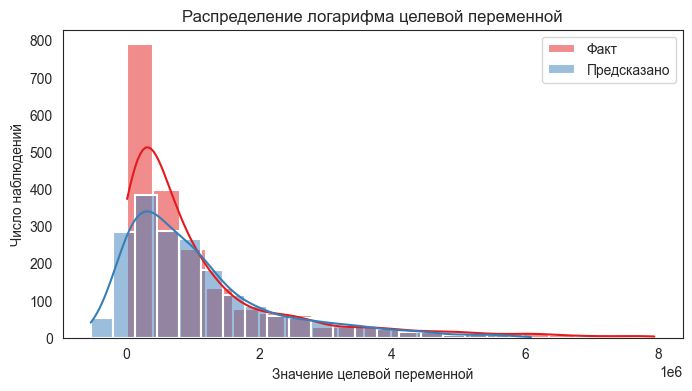

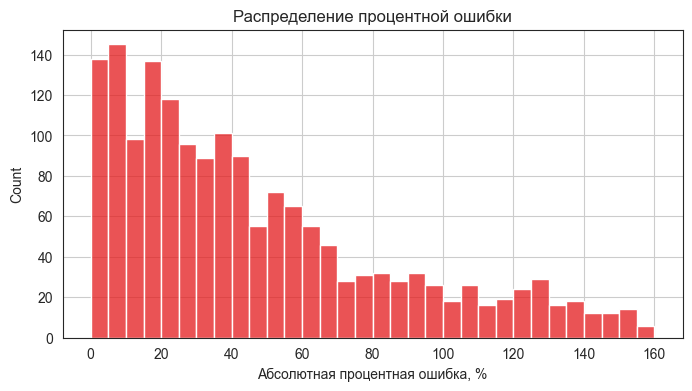

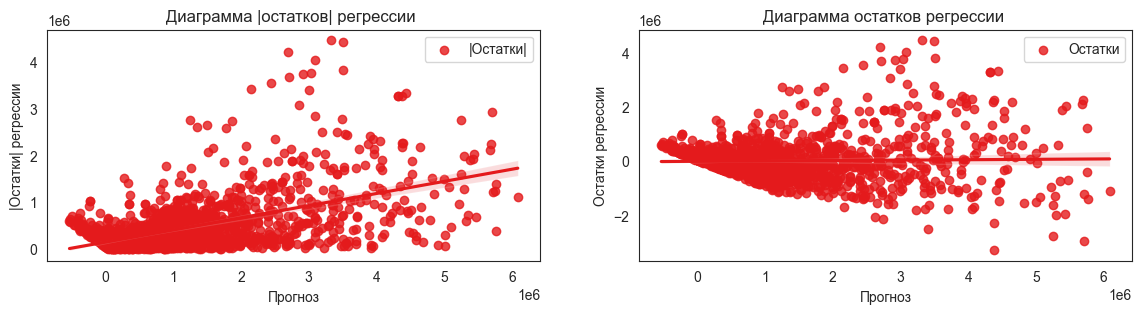

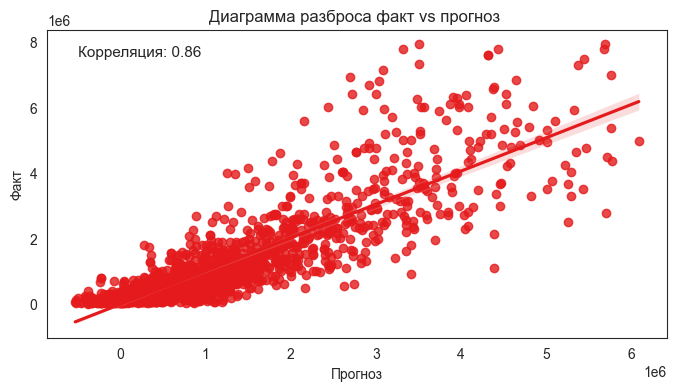

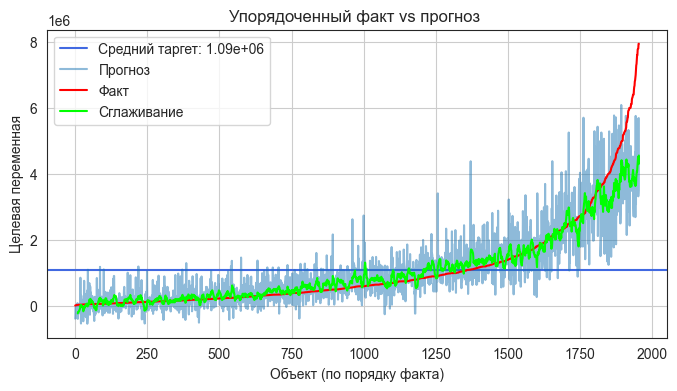

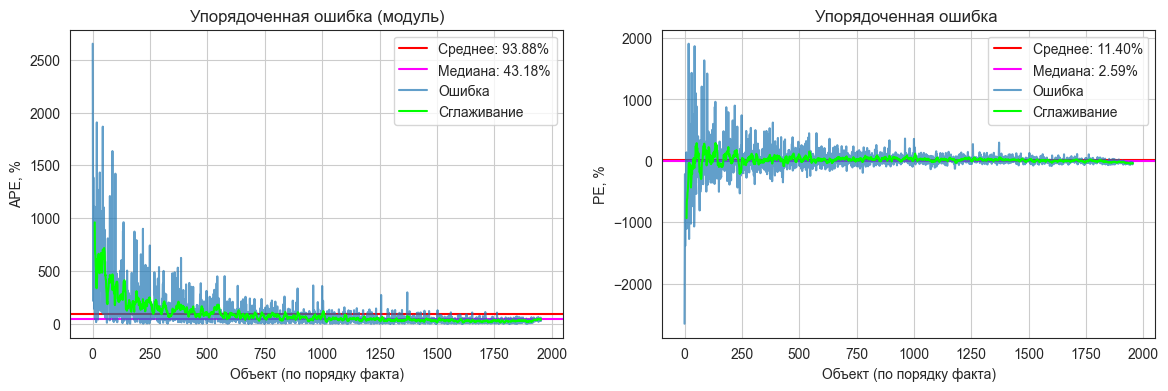

In [29]:
# params = study.best_trial.params
# params.update(FIXED_KWARGS)

model = Ridge().fit(X_train_base, y_train)
y_test_pred = model.predict(X_test_base)

print_metrics(y_train, y_pred, "train")
print()
print_metrics(y_test, y_test_pred, "test")

viz.plot_target_hist(y_test, y_test_pred)
viz.plot_ape_bins(y_test, y_test_pred)
viz.plot_regression_residuals(y_test, y_test_pred)
viz.plot_scatter(y_test, y_test_pred)
viz.plot_predict_sorted(y_test.values, y_test_pred, window=10)
viz.plot_ape_sorted(y_test.values, y_test_pred, window=10)

## CatBoost

In [30]:
from catboost import CatBoostRegressor

model = CatBoostRegressor(verbose=False).fit(X_train_base, y_train)
y_pred = model.predict(X_train_base)
y_test_pred = model.predict(X_test_base)

print_metrics(y_train, y_pred, "train")
print()
print_metrics(y_test, y_test_pred, "test")

train metrics:
	  R2: 97.31%
	RMSE: 224766.96 руб.
	MAPE: 26.06%

test metrics:
	  R2: 87.98%
	RMSE: 471127.39 руб.
	MAPE: 36.42%


In [31]:
!pip install shap

In [32]:
import shap

explainer = shap.TreeExplainer(model)

N_SAMPLE = 5000
if X_train_base.shape[0] > N_SAMPLE:
    X_shap = X_train_base.sample(N_SAMPLE, random_state=42)
else:
    X_shap = X_train_base

shap_values = explainer.shap_values(X_shap)
shap_imp = pd.Series(np.abs(shap_values).mean(axis=0), index=X_shap.columns).sort_values(ascending=False)


C:\Users\timof\miniconda3\envs\sirius\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


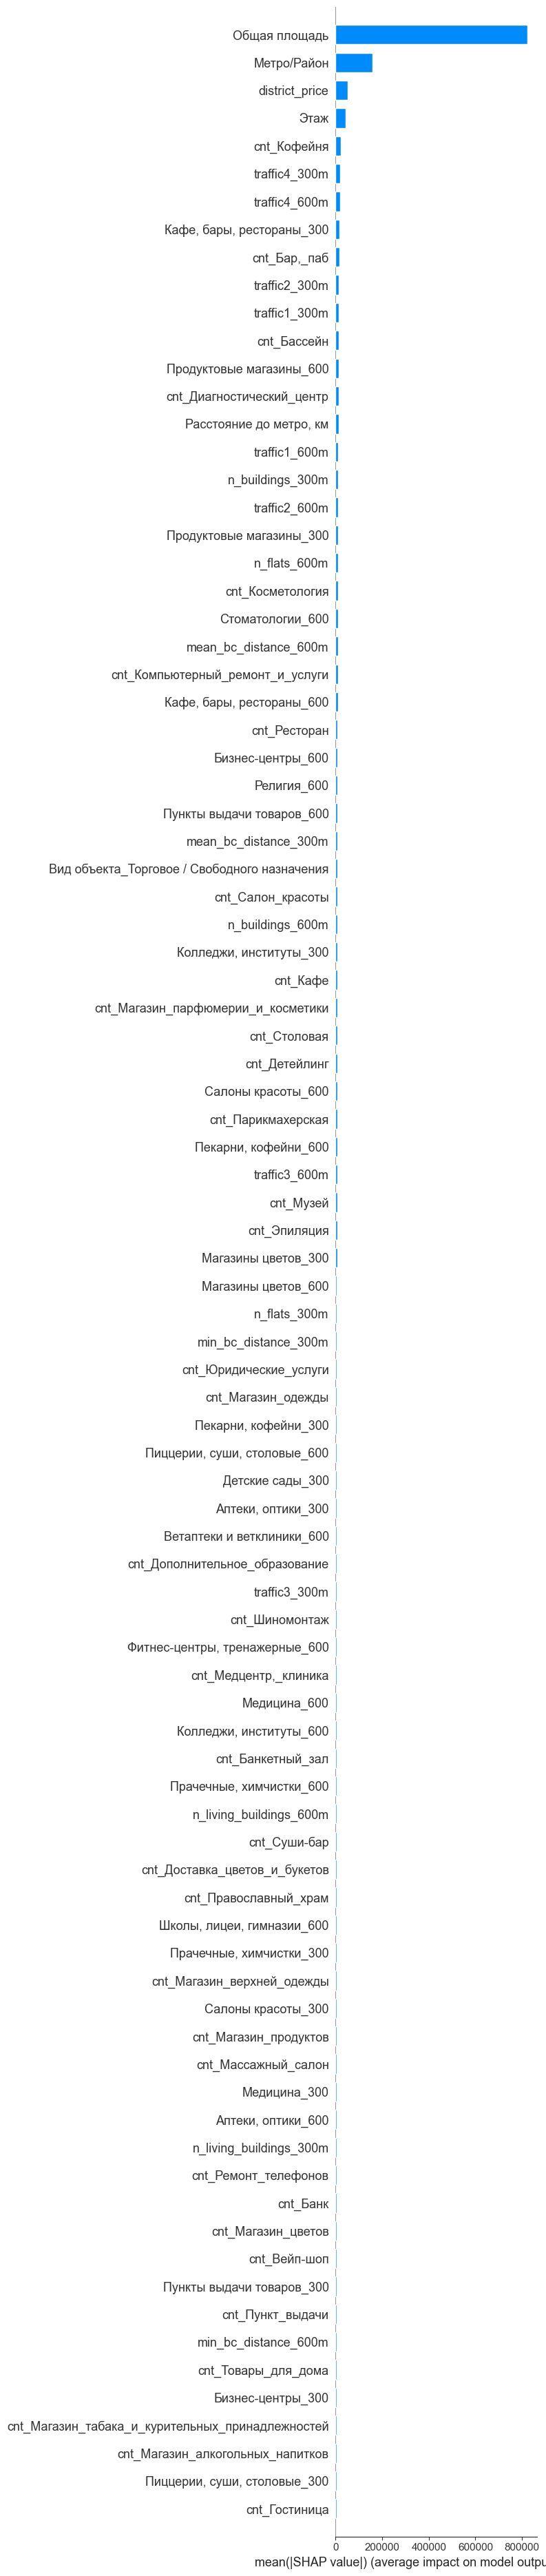

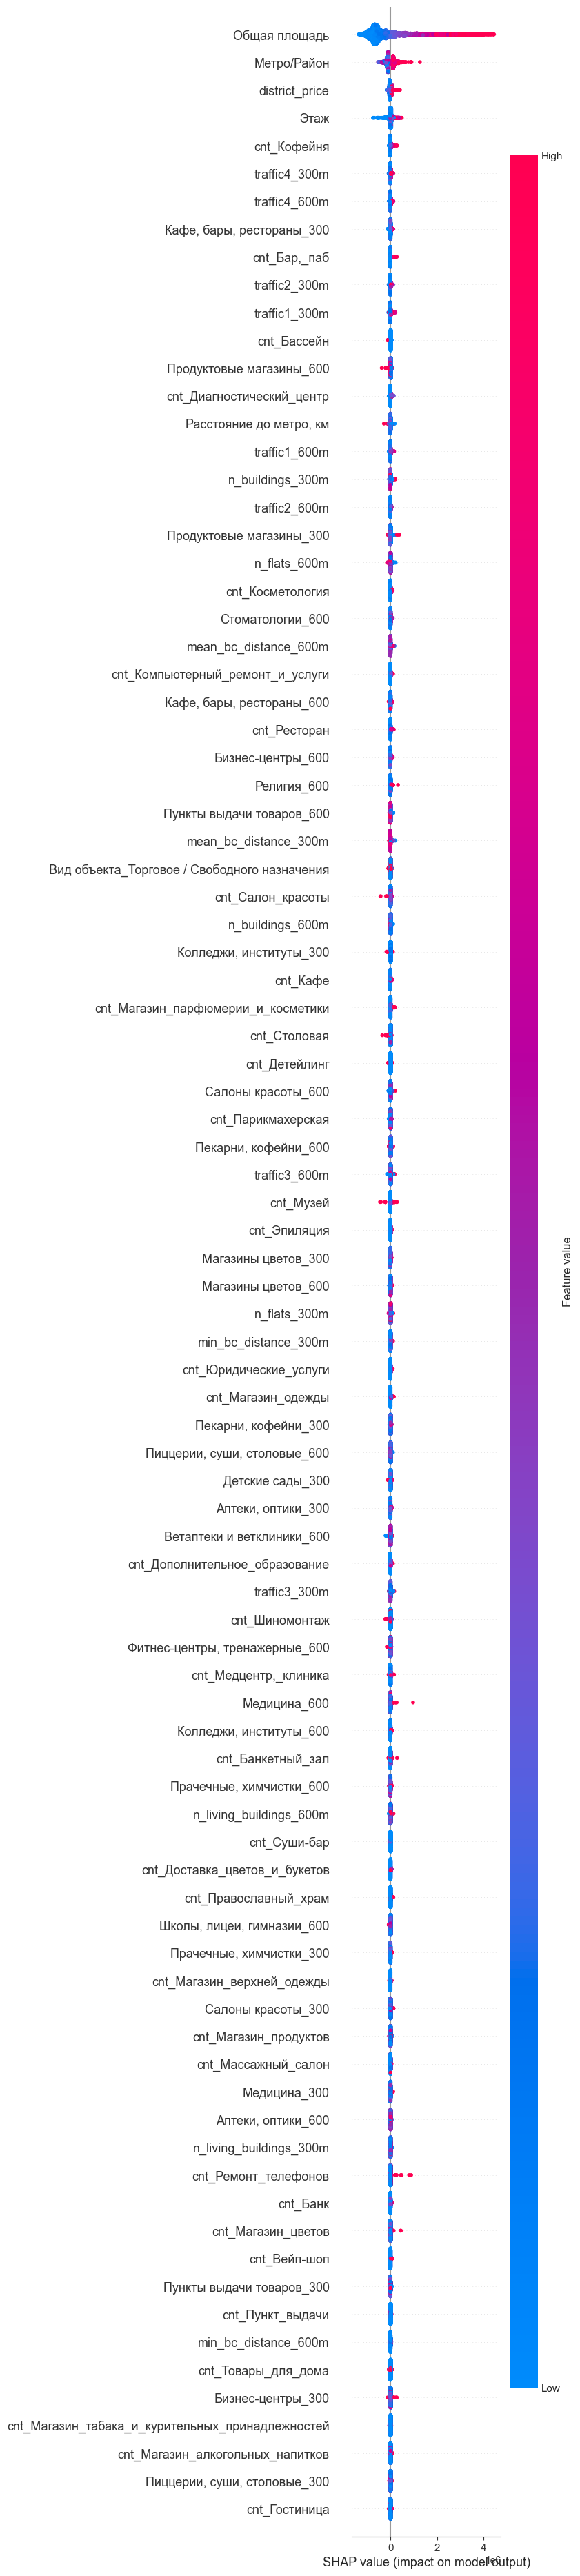

In [33]:
plt.figure(figsize=(8,6))
shap.summary_plot(shap_values, X_shap, plot_type="bar", max_display=90)
shap.summary_plot(shap_values, X_shap, plot_type="dot", max_display=90)

In [34]:
n = 25
top_n_features = shap_imp.head(n).index.tolist()
print("Top", n, "features:", top_n_features)

X_train_top = X_train_base[top_n_features]
X_test_top  = X_test_base[top_n_features]

from catboost import CatBoostRegressor

model_top = CatBoostRegressor(verbose=False)
model_top.fit(X_train_top, y_train)

y_pred_train = model_top.predict(X_train_top)
y_pred_test  = model_top.predict(X_test_top)

print_metrics(y_train, y_pred_train, "train")
print()
print_metrics(y_test, y_pred_test, "test")

Top 25 features: ['Общая площадь', 'Метро/Район', 'district_price', 'Этаж', 'cnt_Кофейня', 'traffic4_300m', 'traffic4_600m', 'Кафе, бары, рестораны_300', 'cnt_Бар,_паб', 'traffic2_300m', 'traffic1_300m', 'cnt_Бассейн', 'Продуктовые магазины_600', 'cnt_Диагностический_центр', 'Расстояние до метро, км', 'traffic1_600m', 'n_buildings_300m', 'traffic2_600m', 'Продуктовые магазины_300', 'n_flats_600m', 'cnt_Косметология', 'Стоматологии_600', 'mean_bc_distance_600m', 'cnt_Компьютерный_ремонт_и_услуги', 'Кафе, бары, рестораны_600']
train metrics:
	  R2: 96.99%
	RMSE: 237615.38 руб.
	MAPE: 27.46%

test metrics:
	  R2: 87.53%
	RMSE: 479886.54 руб.
	MAPE: 37.70%


In [35]:
# FIXED_KWARGS = {
#     'logging_level': 'Silent',
#     'loss_function': 'RMSE',
#     'random_state': 10,
# }

# def objective(trial, X, y):
#     params = {
#         'iterations': trial.suggest_categorical('iterations', [50, 100, 200, 300, 500, 750, 1000]),
#         'depth': trial.suggest_int('depth', low=3, high=6),
#         'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', low=1e-6, high=100.0, log=True),
#         'learning_rate': trial.suggest_float('learning_rate', low=1e-4, high=5e-1), # log=True
#         'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', low=5, high=25),
#         'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.3, 1.0),
#         'subsample': trial.suggest_float('subsample', low=0.3, high=1.0),
#         'early_stopping_rounds': 200,
#     }
    
#     params.update(FIXED_KWARGS)
#     model = CatBoostRegressor(**params).fit(X, y)
#     scores = cross_validate(
#         model,
#         X, y,
#         scoring="r2", # https://scikit-learn.org/stable/modules/model_evaluation.html
#         cv=CV,
#         n_jobs=-1,
#     )
#     return scores['test_score'].mean()

In [36]:
# study = optuna.create_study(
#         sampler=optuna.samplers.TPESampler(),
#         pruner=optuna.pruners.HyperbandPruner(),
#         direction="maximize",
# )

# study.optimize(lambda trial: objective(trial, X_train_base, y_train),
#                   n_trials=1000, timeout=600, gc_after_trial=True, show_progress_bar=True)

# study_results(study)
# plot_study(study)

In [37]:
# params = study.best_trial.params
# params.update(FIXED_KWARGS)

# model = CatBoostRegressor(**params).fit(X_train_base, y_train)
# y_pred = model.predict(X_train_base)
# y_test_pred = model.predict(X_test_base)

# print_metrics(y_train, y_pred, "train")
# print()
# print_metrics(y_test, y_test_pred, "test")

# viz.plot_target_hist(y_test, y_test_pred)
# viz.plot_ape_bins(y_test, y_test_pred)
# viz.plot_regression_residuals(y_test, y_test_pred)
# viz.plot_scatter(y_test, y_test_pred)
# viz.plot_predict_sorted(y_test.values, y_test_pred, window=10)
# viz.plot_ape_sorted(y_test.values, y_test_pred, window=10)